Osmý týden pythonu pro fyziky!!!

In [3]:
import scipy.integrate as solver
import numpy as np
import matplotlib.pyplot as plt

In [4]:
def vlnka(x,y):
    return np.cos(x)
x = np.linspace(0, np.pi, 1000)
result = solver.solve_ivp(vlnka, (0, np.pi), [0], t_eval=x)

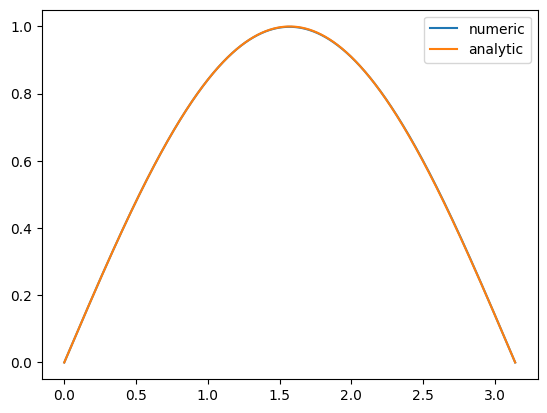

In [5]:
result.y[0,:]
plt.plot(x, result.y[0,:], label = 'numeric')
plt.plot(x, np.sin(x), label = 'analytic')
plt.legend()

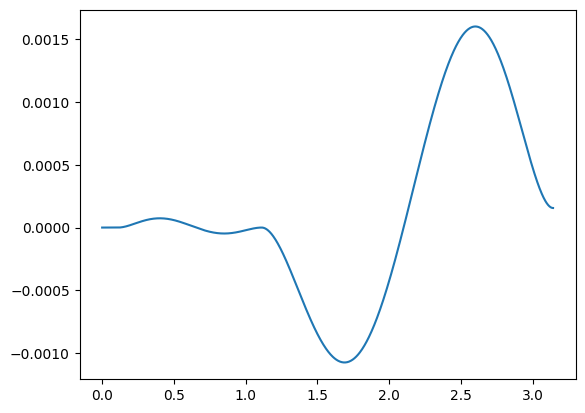

In [6]:
plt.plot(x, result.y[0,:]-np.sin(x))

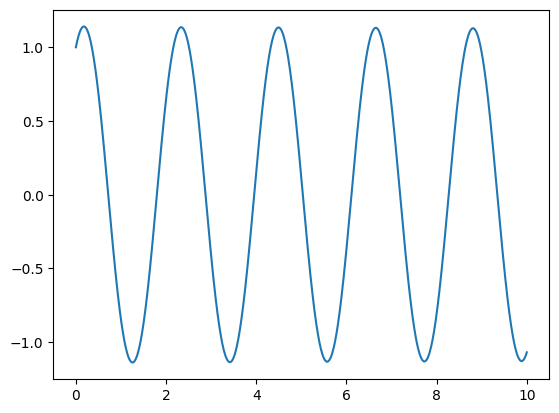

In [7]:
omega = 10/1
def kyv(x,y):
    return [y[1], -1 * omega * np.sin(y[0])]
e_span = np.linspace(0,10,1001)
kmity = solver.solve_ivp(kyv, (0,10), [1,0.5 * np.pi], t_eval=e_span)
plt.plot(e_span, kmity.y[0,:])

In [71]:
gaccel = 10
def no_air(t,y):
    # y[0],y[2] .. [x,y]
    # y[1],y[3] .. [vx,vy]
    r = [y[1],y[3]]
    v = [0, -gaccel]
    return [r[0], v[0], r[1], v[1]]

rad = 180 / np.pi
alpha = 30 / rad
v0 = 42 # m/s
y0 = [0, v0*np.cos(alpha), 0, v0*np.sin(alpha)]

a = 0
b = 4
times = np.linspace(a,b,100)
result = solver.solve_ivp(no_air, (a,b), y0, t_eval=times)

Text(0.5, 1.0, 'Vrh')

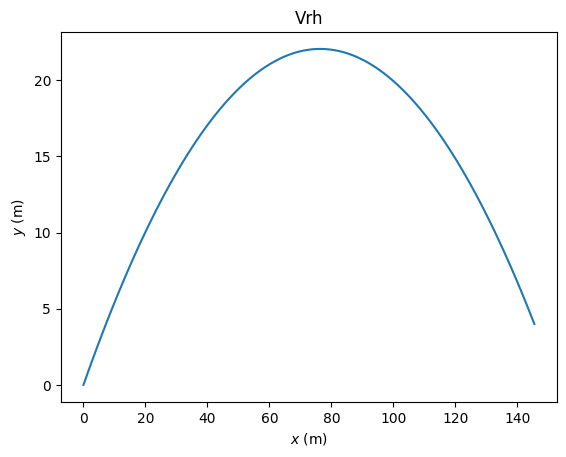

In [41]:
x = result.y[0,:]
y = result.y[2,:]
plt.plot(x,y)
#plt.scatter(x,y,marker = '.', color = 'red')
plt.xlabel('$x$ (m)')
plt.ylabel('$y$ (m)')
plt.title('Vrh')

In [108]:
gaccel = 10
k = 1e-3
def air(t,y):

    v = np.hypot(y[1], y[3])
    Fa = -k*v*np.array([y[1],y[2]])

    # y[0],y[2] .. [x,y]
    # y[1],y[3] .. [vx,vy]

    r = [y[1],y[3]]
    v = [0, -gaccel]

    return [r[0], v[0]+Fa[0], r[1], v[1]+Fa[1]]

rad = 180 / np.pi
alpha = 30 / rad
v0 = 42 # m/s
y0 = [0, v0*np.cos(alpha), 0, v0*np.sin(alpha)]

a = 0
b = 4
times = np.linspace(a,b,50)
result_air = solver.solve_ivp(air, (a,b), y0, t_eval=times)

Text(0.5, 1.0, 'Vrh')

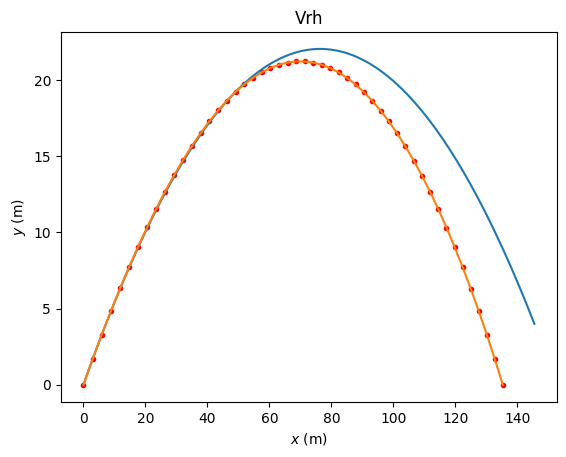

In [109]:
x = result.y[0,:]
y = result.y[2,:]
plt.plot(x,y)

x = result_air.y[0,:]
y = result_air.y[2,:]
plt.plot(x,y)
plt.scatter(x,y,marker = '.', color = 'red')
plt.xlabel('$x$ (m)')
plt.ylabel('$y$ (m)')
plt.title('Vrh')

[]

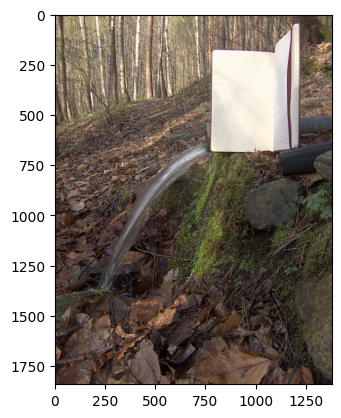

In [188]:
gaccel = 10
k = 1e-3
def air(t,y):

    v = np.hypot(y[1], y[3])
    Fa = -k*v*np.array([y[1],y[2]])

    # y[0],y[2] .. [x,y]
    # y[1],y[3] .. [vx,vy]

    r = [y[1],y[3]]
    v = [0, gaccel]

    return [r[0], v[0]+Fa[0], r[1], v[1]+Fa[1]]

rad = 180 / np.pi
alpha = 30 / rad
v0 = 50 # m/s
y0 = [-700, v0*np.cos(alpha), 0, 0]

a = 0
b = 10
times = np.linspace(a,b,1000)
result_air = solver.solve_ivp(air, (a,b), y0, t_eval=times)

Text(0.5, 1.0, 'Vrh')

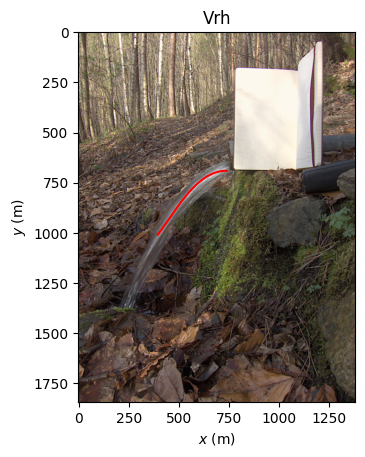

In [ ]:
x = -result_air.y[0,:]+40
y = result_air.y[2,:]+690
plt.imshow(plt.imread('/home/fildapanko/Downloads/IMG_1918.jpg'))
plt.plot(x,y, color ='red')
plt.xlabel('$x$ (m)')
plt.ylabel('$y$ (m)')
plt.title('Vrh')